# Team Model Family Benchmark — Worker 1/5

Notebook แบบ **standalone** นี้เป็นเวอร์ชันรวมจาก **`01-model-search-lab.ipynb`** และ **`02-model-family-search-lab.ipynb`** สำหรับแบ่งรัน 5 คน โดยใช้ **training protocol เดียวกันทุกคน** และเปลี่ยนเฉพาะ architecture ที่ได้รับมอบหมาย

สิ่งที่ล็อกเหมือนกันทั้งทีม:
- `SEED = 42`, `IMAGE_SIZE = 224`, `PAD_VALUE = 255`, `BATCH_SIZE = 32`
- รัน screening `50 epochs/model`, 1 seed (`SEED = 42`)
- pretrained transfer model, freeze 2 epochs, `patience = 5`, `num_workers = 0`
- shared train/validation split และตรวจด้วย `split_hash`
- primary metric = `val_macro_f1`; เก็บ accuracy, minimum recall, parameters, training time และ epoch history ประกอบ
- รอบ distributed screening นี้ **ไม่ทำ HPO/augmentation ablation** เพื่อไม่ให้ recipe ต่างกันระหว่างคน

## การแบ่งงานทั้งทีม

| Worker | จำนวนรัน | Cost score | Families |
|---:|---:|---:|---|
| 1 | 8 | 15 | ResNeSt, MaxViT, ConvMixer, PoolFormer, EfficientNet, EfficientViT-MIT, GhostNet, FasterNet |
| 2 | 8 | 15 | SE-ResNet, ConvNeXt, Swin-Transformer, DeiT, MixNet, TinyViT, MobileNetV2, StarNet |
| 3 | 8 | 15 | Res2Net, InceptionNeXt, ECA-ResNet, HRNet, PVTv2, EdgeNeXt, MobileNetV3, MobileOne |
| 4 | 8 | 15 | ResNeXt, RDNet, DLA, RegNet, ViT, FastViT, MobileNetV4, RepViT |
| 5 | 9 | 15 | EfficientNetV2, CAFormer, DenseNet, RepVGG, ResNet, ReXNet, MobileViT, ConvNeXtV2 + CustomCNN |

Worker 1 รับผิดชอบ 8 timm families.


## 1. ตั้งค่าก่อนรัน

Notebook นี้รันเดี่ยวได้ ไม่ต้อง clone repo และไม่ต้องตั้ง path ไปยัง `src/`

ปกติแก้เฉพาะ `MODE`, `DEVICE`, `BATCH_SIZE`, `WORK_ROOT` หรือ `OUTPUT_ROOT` เท่านั้น ข้อมูลจะดาวน์โหลดจาก Google Drive และแตกไฟล์แบบ cache อัตโนมัติ

- `DEVICE = "auto"` จะเลือก CUDA ก่อน ตามด้วย Apple MPS และ CPU
- ถ้า GPU OOM ให้ลด `BATCH_SIZE` ด้วยค่าเดียวกันทั้ง 5 คน แล้วรันรอบนั้นใหม่ทั้งหมด
- ถ้า Google Drive เปลี่ยนไฟล์ ให้ตั้ง `FORCE_DOWNLOAD = True` หนึ่งครั้ง


In [1]:
from pathlib import Path
import sys

WORKER_ID = 1
MODE = "quick"  # ใช้แยกโฟลเดอร์ผล; จำนวน epoch กำหนดด้านล่าง
SEED = 42
EPOCHS_PER_MODEL = 50
PATIENCE = 50  # ให้รันครบ 50 epochs; ลดค่านี้เมื่อต้องการ early stopping
DEVICE = "auto"
IMAGE_SIZE = 224
BATCH_SIZE = 32
PAD_VALUE = 255
EXPECTED_CLASSES = 72
LABEL_LEVEL = 1

DRIVE_FILE_ID = "1JWrSgLQaHPdpkbXrs9e542TLzxMbSoa0"
DRIVE_URL = f"https://drive.google.com/file/d/{DRIVE_FILE_ID}/view"
WORK_ROOT = Path.cwd() / "team2_workspace"
DATA_CACHE_ROOT = Path.home() / ".cache" / "kmitl_team2_data"  # shared cache: โหลดครั้งเดียวต่อเครื่อง
OUTPUT_ROOT = ""  # เว้นว่างเพื่อใช้ WORK_ROOT/results/...
FORCE_DOWNLOAD = False
EXPECTED_SPLIT_HASH = ""  # ใส่ hash กลางหลังสร้าง split ครั้งแรกได้

INCLUDE_CUSTOM_CNN = False
ALLOW_PARTIAL_RESULTS = True

ASSIGNED_CANDIDATES = [('ResNeSt', 'resnest50d', 'Attention CNN', 'core', 'high', 'split attention เลือก feature branch ที่สำคัญต่อรูปตัวอักษร'), ('MaxViT', 'maxvit_tiny_tf_224', 'Hybrid', 'extended', 'high', 'ผสม convolution กับ block/grid attention; คุ้มเป็นตัวแทน hybrid ที่หนักกว่า'), ('ConvMixer', 'convmixer_768_32', 'Token mixer', 'extended', 'high', 'แยก spatial/channel mixing ด้วย conv; ตัวนี้เล็กด้าน params แต่ฝึกอาจช้า'), ('PoolFormer', 'poolformer_s12', 'Token mixer', 'core', 'medium', 'ใช้ pooling ผสม tokens ทดสอบว่าต้องมี attention เสมอหรือไม่'), ('EfficientNet', 'efficientnet_b0', 'Efficient CNN', 'core', 'low', 'compound scaling ให้ reference ของ accuracy ต่อจำนวนพารามิเตอร์'), ('EfficientViT-MIT', 'efficientvit_b0', 'Efficient Transformer', 'extended', 'low', 'multi-scale linear attention ทดสอบบริบทหลาย scale ด้วยต้นทุนต่ำ; เป็นส่วนต่อยอดจาก CNN'), ('GhostNet', 'ghostnet_100', 'Mobile CNN', 'extended', 'low', 'สร้าง feature เพิ่มด้วย cheap operations ทดสอบความซ้ำซ้อนของ channel'), ('FasterNet', 'fasternet_t0', 'Modern CNN', 'extended', 'low', 'partial convolution ทดสอบความเร็วจริงแทนการสรุปจาก FLOPs')]


## 2. เตรียม dependencies, ดาวน์โหลดข้อมูล และ standalone helpers

ครั้งแรกจะดาวน์โหลด ZIP ประมาณ 1 GB จาก Google Drive; ครั้งต่อไปใช้ไฟล์ที่ cache ไว้ใน `DATA_CACHE_ROOT` และไม่ดาวน์โหลดซ้ำ


In [2]:
WORK_ROOT = Path(WORK_ROOT).expanduser().resolve()
DATA_CACHE_ROOT = Path(DATA_CACHE_ROOT).expanduser().resolve()
WORK_ROOT.mkdir(parents=True, exist_ok=True)

training_budgets = {
    "smoke": {"benchmark": 2, "hpo_epochs": 2, "trials": 2, "final_epochs": 2, "seeds": (42,)},
    "quick": {"benchmark": EPOCHS_PER_MODEL, "hpo_epochs": 6, "trials": 8, "final_epochs": 20, "seeds": (42,)},
    "full": {"benchmark": EPOCHS_PER_MODEL, "hpo_epochs": 8, "trials": 12, "final_epochs": 30, "seeds": (42, 123)},
}
if MODE not in training_budgets:
    raise ValueError(f"MODE ต้องเป็น smoke/quick/full ไม่ใช่ {MODE}")
training_budget = training_budgets[MODE]

import importlib.util
import subprocess

packages = {
    "torch": "torch", "torchvision": "torchvision", "timm": "timm",
    "numpy": "numpy", "pandas": "pandas", "sklearn": "scikit-learn",
    "matplotlib": "matplotlib", "PIL": "Pillow", "gdown": "gdown",
    "openpyxl": "openpyxl",
}
missing = [distribution for module, distribution in packages.items() if importlib.util.find_spec(module) is None]
if missing:
    print("ติดตั้ง dependencies ที่ยังขาด:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("dependencies พร้อมแล้ว")

print("workspace:", WORK_ROOT)
print("worker:", WORKER_ID, "mode:", MODE)
print(f"benchmark: {training_budget['benchmark']} epochs/model | seed: {SEED}")


ติดตั้ง dependencies ที่ยังขาด: ['openpyxl']
workspace: /Users/thawaree.kha/kmitl-deeplearn-project1/notebooks/team2/team2_workspace
worker: 1 mode: quick
benchmark epochs/model: 6



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


/Users/thawaree.kha/kmitl-deeplearn-project1/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


กำลังดาวน์โหลด dataset จาก https://drive.google.com/file/d/1JWrSgLQaHPdpkbXrs9e542TLzxMbSoa0/view


Downloading...
From (original): https://drive.google.com/uc?id=1JWrSgLQaHPdpkbXrs9e542TLzxMbSoa0
From (redirected): https://drive.google.com/uc?id=1JWrSgLQaHPdpkbXrs9e542TLzxMbSoa0&confirm=t&uuid=0965efe2-00da-4b08-8cb5-5cc70870fb7b
To: /Users/thawaree.kha/kmitl-deeplearn-project1/notebooks/team2/team2_data/clean_32x32.zip
100%|██████████| 144M/144M [00:08<00:00, 17.1MB/s] 


กำลังแตกไฟล์: /Users/thawaree.kha/kmitl-deeplearn-project1/notebooks/team2/team2_data/clean_32x32.zip
data: /Users/thawaree.kha/kmitl-deeplearn-project1/notebooks/team2/team2_data/clean_32x32
categories: ['consonants', 'digits', 'special_symbols', 'tone_marks', 'vowels']
previewed categories: 5 | expected total classes: 72


/var/folders/0b/pxgwyp4d2p1dnnfw321vr_9r0000gp/T/ipykernel_46708/1007080310.py:80: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0b/pxgwyp4d2p1dnnfw321vr_9r0000gp/T/ipykernel_46708/1007080310.py:80: UserWarning: Glyph 3671 (\N{THAI DIGIT SEVEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0b/pxgwyp4d2p1dnnfw321vr_9r0000gp/T/ipykernel_46708/1007080310.py:80: UserWarning: Glyph 3654 (\N{THAI CHARACTER MAIYAMOK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0b/pxgwyp4d2p1dnnfw321vr_9r0000gp/T/ipykernel_46708/1007080310.py:80: UserWarning: Glyph 95 (_) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/0b/pxgwyp4d2p1dnnfw321vr_9r0000gp/T/ipykernel_46708/1007080310.py:80: UserWarning: Glyph 3650 (\N{THAI CHARACTER SARA O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/thawaree.kha/kmitl-deeplearn-project1/.venv/lib/python3.14/site-packages

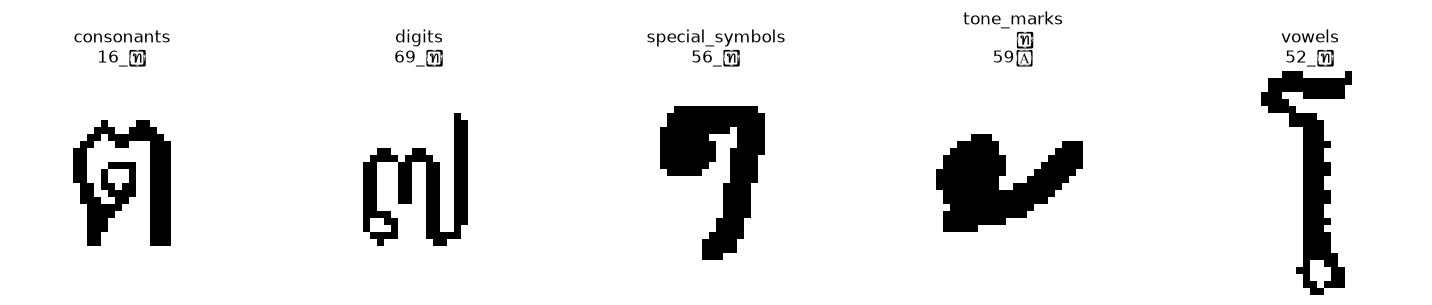

In [3]:
import csv
import gc
import hashlib
import importlib.metadata
import json
import random
import time
import uuid
import zipfile
from collections import Counter, defaultdict
from dataclasses import asdict, dataclass, replace
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Iterable

import gdown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import timm
import torch
from IPython.display import display
from PIL import Image, ImageOps, UnidentifiedImageError
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

IMAGE_EXTENSIONS = {".bmp", ".gif", ".jpeg", ".jpg", ".png", ".tif", ".tiff", ".webp"}
archive_path = DATA_CACHE_ROOT / "clean_32x32.zip"
data_path = DATA_CACHE_ROOT / "clean_32x32"

def has_images(path):
    return path.is_dir() and any(
        item.is_file() and item.suffix.lower() in IMAGE_EXTENSIONS
        for item in path.rglob("*")
    )

if MODE != "smoke" and not has_images(data_path):
    DATA_CACHE_ROOT.mkdir(parents=True, exist_ok=True)
    if FORCE_DOWNLOAD or not archive_path.is_file():
        print("กำลังดาวน์โหลด dataset จาก", DRIVE_URL)
        downloaded = gdown.download(id=DRIVE_FILE_ID, output=str(archive_path), quiet=False)
        if not downloaded:
            raise RuntimeError("ดาวน์โหลดไม่สำเร็จ: ตรวจว่า Google Drive ตั้งเป็น Anyone with the link")
    print("กำลังแตกไฟล์:", archive_path)
    with zipfile.ZipFile(archive_path) as archive:
        target = DATA_CACHE_ROOT.resolve()
        for member in archive.infolist():
            destination = (target / member.filename).resolve()
            if destination != target and target not in destination.parents:
                raise ValueError(f"Unsafe path in ZIP: {member.filename}")
        archive.extractall(target)

if MODE != "smoke" and not has_images(data_path):
    candidates = [path for path in DATA_CACHE_ROOT.rglob("clean_32x32") if has_images(path)]
    if len(candidates) != 1:
        raise FileNotFoundError(f"หาโฟลเดอร์ clean_32x32 ไม่เจอแบบชัดเจน: {candidates}")
    data_path = candidates[0]

DATA_PATH = data_path.resolve()
SPLIT_PATH = WORK_ROOT / "data/splits/clean_32x32"
print("data:", DATA_PATH)

if MODE != "smoke":
    categories = sorted(path for path in DATA_PATH.iterdir() if path.is_dir() and not path.name.startswith("."))
    samples = []
    for category in categories:
        sample = next((p for p in category.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS), None)
        if sample:
            samples.append((category.name, sample.parent.name, sample))
    print("categories:", [path.name for path in categories])
    print("previewed categories:", len(samples), "| expected total classes:", EXPECTED_CLASSES)
    fig, axes = plt.subplots(1, len(samples), figsize=(3 * len(samples), 3), squeeze=False)
    for ax, (category, label, path) in zip(axes[0], samples):
        with Image.open(path) as image:
            ax.imshow(image.convert("RGB"))
        ax.set_title(f"{category}\n{label}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()


In [4]:
# Standalone helpers: copied into this notebook so no repository imports are needed.
DEFAULT_EXTENSIONS = {".bmp", ".gif", ".jpeg", ".jpg", ".png", ".tif", ".tiff", ".webp"}

def image_paths(data_dir: Path, extensions: set[str]) -> Iterable[Path]:
    """Yield non-hidden image files recursively in a deterministic order."""
    for path in sorted(data_dir.rglob("*")):
        if not path.is_file() or path.suffix.lower() not in extensions:
            continue
        if any(part.startswith(".") for part in path.relative_to(data_dir).parts):
            continue
        yield path

def label_for_path(path: Path, data_dir: Path, label_level: int) -> str:
    """Read label from the Nth parent directory above an image file.

    label_level=1 maps ``root/class/image.jpg`` to ``class``.
    label_level=2 maps ``root/class/variant/image.jpg`` to ``class``.
    """
    relative_parents = path.relative_to(data_dir).parts[:-1]
    if len(relative_parents) < label_level:
        raise ValueError(
            f"{path} has only {len(relative_parents)} directory level(s) below "
            f"{data_dir}; cannot use --label-level {label_level}."
        )
    return relative_parents[-label_level]

def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

def inspect_image(path: Path) -> tuple[int, int, str]:
    """Validate an image and return width, height, and color mode."""
    if Image is None:
        raise RuntimeError("Pillow is required. Install dependencies with: python3 -m pip install -r requirements.txt")
    try:
        with Image.open(path) as image:
            image.verify()
        with Image.open(path) as image:
            return image.width, image.height, image.mode
    except (UnidentifiedImageError, OSError, ValueError) as error:
        raise ValueError(str(error)) from error

def write_csv(path: Path, fieldnames: list[str], rows: list[dict[str, Any]]) -> None:
    with path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

def audit_dataset(data_dir: Path, output_dir: Path, label_level: int, extensions: set[str]) -> dict[str, Any]:
    """Audit images at data_dir and write reproducible manifests and a JSON report."""
    data_dir = Path(data_dir).expanduser().resolve()
    if not data_dir.exists() or not data_dir.is_dir():
        raise FileNotFoundError(f"Dataset directory does not exist or is not a folder: {data_dir}")
    if label_level < 1:
        raise ValueError("--label-level must be at least 1")
    if Image is None:
        raise RuntimeError("Pillow is required. Install dependencies with: python3 -m pip install -r requirements.txt")

    output_dir.mkdir(parents=True, exist_ok=True)
    records: list[dict[str, Any]] = []
    corrupt: list[dict[str, str]] = []
    label_errors: list[dict[str, str]] = []
    class_counts: Counter[str] = Counter()
    modes: Counter[str] = Counter()
    resolutions: Counter[str] = Counter()
    hashes: dict[str, list[str]] = {}

    paths = list(image_paths(data_dir, extensions))
    for path in paths:
        try:
            label = label_for_path(path, data_dir, label_level)
        except ValueError as error:
            label_errors.append({"path": str(path), "error": str(error)})
            continue
        try:
            width, height, mode = inspect_image(path)
            content_hash = sha256_file(path)
        except (OSError, ValueError) as error:
            corrupt.append({"path": str(path), "error": str(error)})
            continue

        class_counts[label] += 1
        modes[mode] += 1
        resolutions[f"{width}x{height}"] += 1
        hashes.setdefault(content_hash, []).append(str(path))
        records.append(
            {
                "path": str(path.resolve()),
                "label": label,
                "width": width,
                "height": height,
                "mode": mode,
                "sha256": content_hash,
            }
        )

    exact_duplicate_groups = [group for group in hashes.values() if len(group) > 1]
    ordered_counts = sorted(class_counts.items(), key=lambda item: (item[1], item[0]))
    minimum = min(class_counts.values()) if class_counts else None
    maximum = max(class_counts.values()) if class_counts else None
    report: dict[str, Any] = {
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "data_dir": str(data_dir.resolve()),
        "label_level": label_level,
        "extensions": sorted(extensions),
        "discovered_supported_files": len(paths),
        "valid_images": len(records),
        "corrupt_images": len(corrupt),
        "label_errors": len(label_errors),
        "class_count": len(class_counts),
        "images_per_class": dict(sorted(class_counts.items())),
        "minimum_images_per_class": minimum,
        "maximum_images_per_class": maximum,
        "imbalance_ratio_max_over_min": (maximum / minimum) if minimum else None,
        "image_modes": dict(sorted(modes.items())),
        "top_resolutions": dict(resolutions.most_common(20)),
        "exact_duplicate_groups": len(exact_duplicate_groups),
        "images_in_exact_duplicate_groups": sum(len(group) for group in exact_duplicate_groups),
        "notes": [
            "Exact duplicates use SHA-256 hashes. Near-duplicate detection is not included in this first audit.",
            "Inspect image_manifest.csv and class_counts.csv before deciding transformations or class weights.",
        ],
    }

    write_csv(output_dir / "image_manifest.csv", ["path", "label", "width", "height", "mode", "sha256"], records)
    write_csv(
        output_dir / "class_counts.csv",
        ["label", "image_count"],
        [{"label": label, "image_count": count} for label, count in ordered_counts],
    )
    write_csv(output_dir / "corrupt_images.csv", ["path", "error"], corrupt)
    write_csv(output_dir / "label_errors.csv", ["path", "error"], label_errors)
    write_csv(
        output_dir / "exact_duplicate_groups.csv",
        ["sha256", "path"],
        [
            {"sha256": digest, "path": path}
            for digest, group in hashes.items()
            if len(group) > 1
            for path in group
        ],
    )
    (output_dir / "audit_report.json").write_text(json.dumps(report, ensure_ascii=False, indent=2), encoding="utf-8")
    return report

def fingerprint(value) -> str:
    return hashlib.sha256(json.dumps(value, sort_keys=True, ensure_ascii=False).encode()).hexdigest()

def read_rows(path: Path) -> list[dict]:
    with path.open(encoding="utf-8", newline="") as stream:
        return list(csv.DictReader(stream))

def prepare_split(data_dir: Path, audit_dir: Path, split_dir: Path,
                  seed: int = 42, val_fraction: float = 0.2,
                  expected_classes: int | None = 72,
                  conflicting_label_policy: str = "exclude") -> dict:
    """Reuse only an identical split; never silently replace the team's split.

    The target is approximately 80/20 per class: indivisible duplicate groups
    can prevent an exact ratio. By default, every member of a hash group whose
    labels disagree is quarantined from both splits; the source images are not
    modified and the audit directory records the affected paths. Pass
    ``conflicting_label_policy='error'`` to require manual resolution instead.
    """
    if not 0 < val_fraction < 1:
        raise ValueError("val_fraction must be between zero and one")
    if conflicting_label_policy not in {"exclude", "error"}:
        raise ValueError("conflicting_label_policy must be 'exclude' or 'error'")
    data_dir = data_dir.resolve()
    rows = read_rows(audit_dir / "image_manifest.csv")
    if not rows:
        raise ValueError("No valid images. Check DATA_DIR, archives and LABEL_LEVEL.")
    for row in rows:
        row["path"] = Path(row["path"]).resolve().relative_to(data_dir).as_posix()
    rows = sorted(({k: row[k] for k in ("path", "label", "sha256")} for row in rows),
                  key=lambda row: row["path"])
    source_rows = rows
    labels = sorted({row["label"] for row in rows})
    if expected_classes is not None and len(labels) != expected_classes:
        raise ValueError(f"Expected {expected_classes} classes, found {len(labels)}. Check label folders.")
    if len(labels) < 2:
        raise ValueError("Classification needs at least two classes")
    groups = defaultdict(list)
    for row in rows:
        groups[row["sha256"]].append(row)
    conflicting_groups = [group for group in groups.values() if len({row["label"] for row in group}) > 1]
    excluded_rows = sorted((row for group in conflicting_groups for row in group), key=lambda row: row["path"])
    write_csv(audit_dir / "conflicting_label_duplicates.csv", ["path", "label", "sha256"], excluded_rows)
    if conflicting_groups and conflicting_label_policy == "error":
        raise ValueError("Identical files have conflicting labels; see conflicting_label_duplicates.csv and resolve them before splitting.")
    if excluded_rows:
        excluded_hashes = {row["sha256"] for row in excluded_rows}
        rows = [row for row in rows if row["sha256"] not in excluded_hashes]
        groups = defaultdict(list)
        for row in rows:
            groups[row["sha256"]].append(row)
        labels = sorted({row["label"] for row in rows})
        if expected_classes is not None and len(labels) != expected_classes:
            raise ValueError("Excluding conflicting duplicates removed a class; resolve labels manually before splitting.")
        if len(labels) < 2:
            raise ValueError("Classification needs at least two classes after excluding conflicting duplicates")
    label_map = {label: i for i, label in enumerate(labels)}
    identity = {"dataset_hash": fingerprint(source_rows), "seed": seed,
                "val_fraction": val_fraction, "algorithm": "sha256-label-greedy-v2",
                "conflicting_label_policy": conflicting_label_policy,
                "excluded_conflicting_hashes": len(conflicting_groups),
                "excluded_conflicting_images": len(excluded_rows)}
    split_dir.mkdir(parents=True, exist_ok=True)
    meta_path = split_dir / "split_meta.json"
    if any(split_dir.iterdir()):
        required = [meta_path, split_dir / "train.csv", split_dir / "val.csv",
                    split_dir / "label_to_index.json"]
        if not all(path.is_file() for path in required):
            raise ValueError("Incomplete/external split directory. Use a new SPLIT_DIR or restore all shared files.")
        meta = json.loads(meta_path.read_text())
        if any(meta.get(key) != value for key, value in identity.items()):
            raise ValueError("Dataset or split settings changed. Restore team data/settings or use a new SPLIT_DIR.")
        if json.loads(required[-1].read_text()) != label_map:
            raise ValueError("Label mapping was modified")
        if fingerprint([read_rows(required[1]), read_rows(required[2]), label_map]) != meta["split_hash"]:
            raise ValueError("Frozen manifests were modified")
        return meta
    rng = random.Random(seed)
    train, val, train_only_classes = [], [], []
    for label in labels:
        buckets = [group for group in groups.values() if group[0]["label"] == label]
        if len(buckets) < 2:
            # A singleton class cannot appear in both partitions without data
            # leakage. Keep its real example in training and expose this fact
            # in metadata so validation metrics are interpreted correctly.
            train.extend(row for group in buckets for row in group)
            train_only_classes.append(label)
            continue
        rng.shuffle(buckets)
        target = sum(map(len, buckets)) * val_fraction
        # Start with the closest-sized group, not an arbitrary huge duplicate
        # group. Reserve at least one whole group for training.
        first = min(range(len(buckets)), key=lambda i: abs(len(buckets[i]) - target))
        chosen, remaining = list(buckets.pop(first)), []
        count = len(chosen)
        for index, group in enumerate(buckets):
            if index < len(buckets) - 1 and abs(count + len(group) - target) < abs(count - target):
                chosen.extend(group)
                count += len(group)
            else:
                remaining.extend(group)
        train.extend(remaining)
        val.extend(chosen)
    train.sort(key=lambda row: row["path"])
    val.sort(key=lambda row: row["path"])
    meta = {**identity, "split_hash": fingerprint([train, val, label_map]),
            "train_images": len(train), "val_images": len(val),
            "source_images": len(source_rows), "included_images": len(rows),
            "actual_val_fraction": len(val) / len(rows), "num_classes": len(labels),
            "train_only_classes": train_only_classes}
    write_csv(split_dir / "train.csv", ["path", "label", "sha256"], train)
    write_csv(split_dir / "val.csv", ["path", "label", "sha256"], val)
    (split_dir / "label_to_index.json").write_text(json.dumps(label_map, ensure_ascii=False, indent=2))
    meta_path.write_text(json.dumps(meta, indent=2))
    return meta

@dataclass
class TrainConfig:
    architecture: str = "resnet18"
    pretrained: bool = True
    seed: int = 42
    image_size: int = 224
    batch_size: int = 32
    epochs: int = 12
    freeze_epochs: int = 2
    head_lr: float = 1e-3
    finetune_lr: float = 1e-4
    weight_decay: float = 1e-4
    dropout: float = 0.3
    label_smoothing: float = 0.0
    augmentation: bool = False
    class_weights: bool = False
    patience: int = 5
    num_workers: int = 0  # Portable in Jupyter on macOS, Windows and Colab.
    amp: bool = True
    device: str = "auto"
    # Fixed ImageNet statistics for a controlled cross-backbone benchmark.
    mean: tuple = (0.485, 0.456, 0.406)
    std: tuple = (0.229, 0.224, 0.225)
    pad_value: int = 255

def save_json(path: Path, value) -> None:
    path.write_text(json.dumps(value, indent=2, ensure_ascii=False), encoding="utf-8")

class ResizePad:
    def __init__(self, size: int, fill: int):
        self.size, self.fill = size, fill

    def __call__(self, image):
        return ImageOps.pad(image, (self.size, self.size), method=Image.Resampling.BILINEAR,
                            color=(self.fill,) * 3)

def make_transform(config: TrainConfig, training: bool = False):
    operations = [ResizePad(config.image_size, config.pad_value)]
    if training and config.augmentation:
        operations.append(transforms.RandomAffine(
            degrees=5, translate=(0.03, 0.03), scale=(0.95, 1.05),
            interpolation=transforms.InterpolationMode.BILINEAR,
            fill=(config.pad_value,) * 3))
    return transforms.Compose(operations + [transforms.ToTensor(), transforms.Normalize(config.mean, config.std)])

class ManifestDataset(Dataset):
    def __init__(self, root: Path, rows: list[dict], mapping: dict, transform):
        self.root, self.rows, self.mapping, self.transform = root, rows, mapping, transform

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, index):
        row = self.rows[index]
        with Image.open(self.root / row["path"]) as image:
            tensor = self.transform(image.convert("RGB"))
        return tensor, self.mapping[row["label"]]

class CustomCNN(nn.Module):
    def __init__(self, classes: int, dropout: float):
        super().__init__()
        layers, channels = [], 3
        for width in (32, 64, 128, 256):
            layers.extend([nn.Conv2d(channels, width, 3, padding=1), nn.BatchNorm2d(width),
                           nn.ReLU(), nn.MaxPool2d(2)])
            channels = width
        self.features = nn.Sequential(*layers, nn.AdaptiveAvgPool2d(1), nn.Flatten())
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(256, classes))

    def forward(self, x):
        return self.head(self.features(x))

    def get_classifier(self):
        return self.head

def build_model(config: TrainConfig, classes: int, load_pretrained: bool = True):
    if config.architecture == "custom_cnn":
        return CustomCNN(classes, config.dropout)
    import timm
    return timm.create_model(config.architecture, pretrained=config.pretrained and load_pretrained,
                             num_classes=classes, drop_rate=config.dropout)

def choose_device(name: str):
    name = name.lower()
    if name == "auto":
        name = "cuda" if torch.cuda.is_available() else (
            "mps" if torch.backends.mps.is_available() else "cpu")
    device = torch.device(name)
    if device.type == "cuda":
        if not torch.cuda.is_available():
            raise RuntimeError("CUDA was requested but no CUDA GPU is available to PyTorch")
        if device.index is not None and device.index >= torch.cuda.device_count():
            raise RuntimeError(f"CUDA device {device.index} does not exist")
    elif device.type == "mps" and not torch.backends.mps.is_available():
        raise RuntimeError("MPS was requested but is not available to PyTorch")
    elif device.type not in {"cpu", "cuda", "mps"}:
        raise ValueError("device must be auto, cpu, cuda, cuda:<index>, or mps")
    return device

def device_name(device: torch.device) -> str:
    if device.type == "cuda":
        return torch.cuda.get_device_name(device)
    return "Apple MPS" if device.type == "mps" else "CPU"

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

def seed_worker(worker_id):
    seed = torch.initial_seed() % 2**32
    random.seed(seed)
    np.random.seed(seed)

def load_split(data_dir: Path, split_dir: Path):
    train, val = read_rows(split_dir / "train.csv"), read_rows(split_dir / "val.csv")
    mapping = json.loads((split_dir / "label_to_index.json").read_text())
    meta = json.loads((split_dir / "split_meta.json").read_text())
    if fingerprint([train, val, mapping]) != meta["split_hash"]:
        raise ValueError("Split/mapping hash mismatch. Restore the frozen manifests.")
    if {r["sha256"] for r in train} & {r["sha256"] for r in val}:
        raise ValueError("Duplicate leakage across train and validation")
    for row in train + val:
        path = (data_dir / row["path"]).resolve()
        if not path.is_relative_to(data_dir.resolve()) or not path.is_file():
            raise ValueError(f"Missing/invalid image in manifest: {row['path']}")
    return train, val, mapping, meta

def evaluate(model, loader, device, criterion, classes):
    model.eval()
    actual, predicted, confidence = [], [], []
    total_loss = 0.0
    with torch.inference_mode():
        for images, targets in loader:
            images, targets = images.to(device), targets.to(device)
            logits = model(images)
            total_loss += criterion(logits, targets).sum().item()
            probs = logits.softmax(1)
            scores, indices = probs.max(1)
            actual.extend(targets.cpu().tolist())
            predicted.extend(indices.cpu().tolist())
            confidence.extend(scores.cpu().tolist())
    report = classification_report(actual, predicted, labels=list(range(classes)),
                                   output_dict=True, zero_division=0)
    metrics = {"val_loss": total_loss / len(actual), "val_accuracy": accuracy_score(actual, predicted),
               "val_macro_f1": report["macro avg"]["f1-score"],
               "val_macro_precision": report["macro avg"]["precision"],
               "val_macro_recall": report["macro avg"]["recall"],
               "minimum_per_class_recall": min(report[str(i)]["recall"] for i in range(classes))}
    return metrics, report, actual, predicted, confidence

def fit(config: TrainConfig, data_dir: Path, split_dir: Path, output_dir: Path,
        phase: str = "benchmark", trial=None, reuse: bool = True) -> dict:
    """Reuse completed identical runs; interrupted runs restart in a new directory.

    Trial pruning never produces an eligible completed run. Each checkpoint carries
    its preprocessing, label mapping and split hash for standalone inference.
    """
    if config.image_size < 32 or config.batch_size < 2 or config.epochs < 1:
        raise ValueError("Use image_size >= 32, batch_size >= 2, epochs >= 1")
    if config.patience < 1 or not 0 <= config.freeze_epochs < config.epochs:
        raise ValueError("patience >= 1 and 0 <= freeze_epochs < epochs are required")
    data_dir, split_dir, output_dir = map(lambda p: Path(p).resolve(), (data_dir, split_dir, output_dir))
    train_rows, val_rows, mapping, meta = load_split(data_dir, split_dir)
    code_hash = fingerprint("team2-standalone-training-v1")
    versions = {name: importlib.metadata.version(name) for name in
                ("torch", "torchvision", "timm", "numpy", "scikit-learn")}
    run_key = fingerprint([asdict(config), meta["split_hash"], phase, code_hash, versions])
    output_dir.mkdir(parents=True, exist_ok=True)
    if reuse and trial is None:
        for receipt_path in sorted(output_dir.glob("*/run_receipt.json")):
            receipt = json.loads(receipt_path.read_text())
            if receipt.get("run_key") == run_key and receipt.get("status") == "complete" and all(
                    Path(receipt[k]).is_file() for k in ("checkpoint_path", "metrics_path", "config_path")):
                print("Reusing completed run:", receipt["run_id"])
                return receipt
    seed_everything(config.seed)
    device = choose_device(config.device)
    print(f"Training device: {device} ({device_name(device)})", flush=True)
    run_id = f"{phase}-{config.architecture}-{uuid.uuid4().hex[:10]}"
    run_dir = output_dir / run_id
    run_dir.mkdir()
    save_json(run_dir / "config.json", asdict(config))
    save_json(run_dir / "environment.json", {**versions, "device": str(device),
                                               "device_name": device_name(device), "code_hash": code_hash})
    receipt = {"run_id": run_id, "run_key": run_key, "status": "running", "phase": phase,
               "split_hash": meta["split_hash"], "seed": config.seed, "backbone": config.architecture,
               "max_epochs": config.epochs, "config_path": str(run_dir / "config.json"),
               "checkpoint_path": str(run_dir / "best.pt"), "metrics_path": str(run_dir / "metrics.json")}
    save_json(run_dir / "run_receipt.json", receipt)
    model = optimizer = None
    print(f"Loading {config.architecture}…", flush=True)
    started = time.perf_counter()
    try:
        train_set = ManifestDataset(data_dir, train_rows, mapping, make_transform(config, True))
        val_set = ManifestDataset(data_dir, val_rows, mapping, make_transform(config))
        # Drop a singleton tail: BatchNorm in small backbones can reject it.
        train_loader = DataLoader(train_set, batch_size=config.batch_size, shuffle=True,
                                  num_workers=config.num_workers, pin_memory=device.type == "cuda",
                                  worker_init_fn=seed_worker, generator=torch.Generator().manual_seed(config.seed),
                                  drop_last=len(train_set) % config.batch_size == 1)
        val_loader = DataLoader(val_set, batch_size=config.batch_size, num_workers=config.num_workers)
        model = build_model(config, len(mapping)).to(device)
        print(f"Model ready — training up to {config.epochs} epochs", flush=True)
        weights = None
        if config.class_weights:
            counts = np.bincount([mapping[r["label"]] for r in train_rows], minlength=len(mapping))
            values = np.minimum(np.sqrt(counts.max() / counts), 3.0)
            weights = torch.tensor(values / values.mean(), dtype=torch.float32, device=device)
        criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=config.label_smoothing, reduction="none")
        # Validation loss is always plain CE so loss remains comparable across ablations.
        val_criterion = nn.CrossEntropyLoss(reduction="none")
        use_amp = config.amp and device.type == "cuda"
        scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
        freeze_epochs = config.freeze_epochs if config.pretrained and config.architecture != "custom_cnn" else 0
        history, best, stale = [], (-1.0, -1.0), 0
        for epoch in range(config.epochs):
            frozen = epoch < freeze_epochs
            if epoch in {0, freeze_epochs}:
                for parameter in model.parameters():
                    parameter.requires_grad_(not frozen)
                for parameter in model.get_classifier().parameters():
                    parameter.requires_grad_(True)
                lr = config.head_lr if frozen or config.architecture == "custom_cnn" else config.finetune_lr
                optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad],
                                              lr=lr, weight_decay=config.weight_decay)
                scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.2, patience=2)
                stale = 0
            model.train()
            if frozen:
                model.eval()  # Freeze running BatchNorm statistics as well as gradients.
                model.get_classifier().train()
            total_loss = correct = seen = 0
            for images, targets in train_loader:
                images, targets = images.to(device), targets.to(device)
                optimizer.zero_grad(set_to_none=True)
                with torch.autocast(device_type=device.type, enabled=use_amp):
                    logits = model(images)
                    loss = criterion(logits, targets).mean()
                if not torch.isfinite(loss):
                    raise FloatingPointError("Non-finite training loss")
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                scaler.step(optimizer)
                scaler.update()
                total_loss += loss.item() * len(targets)
                correct += (logits.argmax(1) == targets).sum().item()
                seen += len(targets)
            metrics, report, actual, predicted, confidence = evaluate(model, val_loader, device, val_criterion, len(mapping))
            if not np.isfinite(list(metrics.values())).all():
                raise FloatingPointError("Non-finite validation metrics")
            record = {"epoch": epoch + 1, "stage": "head" if frozen else "finetune",
                      "train_loss": total_loss / seen, "train_accuracy": correct / seen,
                      "lr": optimizer.param_groups[0]["lr"], **metrics}
            history.append(record)
            pd.DataFrame(history).to_csv(run_dir / "history.csv", index=False)
            score = metrics["val_macro_f1"], metrics["val_accuracy"]
            if score > best:
                best, stale = score, 0
                torch.save({"state_dict": {k: v.detach().cpu() for k, v in model.state_dict().items()},
                            "config": asdict(config), "label_to_index": mapping,
                            "split_hash": meta["split_hash"], "best_epoch": epoch + 1}, run_dir / "best.pt")
                save_json(run_dir / "metrics.json", {**metrics, "classification_report": report})
                names = list(mapping)
                pd.DataFrame(confusion_matrix(actual, predicted, labels=list(range(len(mapping)))),
                             index=names, columns=names).to_csv(run_dir / "confusion_matrix.csv")
                pd.DataFrame({"path": [r["path"] for r in val_rows], "true_label": [names[i] for i in actual],
                              "predicted_label": [names[i] for i in predicted], "confidence": confidence}).to_csv(
                                  run_dir / "predictions.csv", index=False)
                receipt.update(metrics, best_epoch=epoch + 1, train_accuracy=record["train_accuracy"])
            else:
                stale += 1
            scheduler.step(metrics["val_macro_f1"])
            print(f"{run_id} | {epoch + 1}/{config.epochs} | loss={record['train_loss']:.4f} "
                  f"val_acc={metrics['val_accuracy']:.4f} macro_f1={metrics['val_macro_f1']:.4f}", flush=True)
            if trial is not None:
                trial.report(best[0], epoch)
                if trial.should_prune():
                    import optuna
                    raise optuna.TrialPruned()
            if not frozen and stale >= config.patience:
                break
        receipt.update(status="complete", epochs_completed=len(history),
                       parameter_count=sum(p.numel() for p in model.parameters()),
                       training_seconds=time.perf_counter() - started)
        save_json(run_dir / "run_receipt.json", receipt)
        return receipt
    except BaseException as error:
        receipt.update(status="pruned" if type(error).__name__ == "TrialPruned" else "failed",
                       error=f"{type(error).__name__}: {error}")
        save_json(run_dir / "run_receipt.json", receipt)
        raise
    finally:
        del model, optimizer
        gc.collect()
        if device.type == "cuda":
            torch.cuda.empty_cache()
        elif device.type == "mps":
            torch.mps.empty_cache()

def rank_runs(receipts):
    return pd.DataFrame(receipts).sort_values(
        ["val_macro_f1", "val_accuracy"], ascending=False
    ).reset_index(drop=True)


device = choose_device(DEVICE)
print("PyTorch:", torch.__version__, "timm:", timm.__version__)
print("device:", device, f"({device_name(device)})")
if device.type == "cuda":
    props = torch.cuda.get_device_properties(device)
    print(f"CUDA ready: {props.name} | VRAM {props.total_memory / 1024**3:.1f} GB | AMP enabled during training")
elif device.type == "mps":
    print("Apple Metal (MPS) พร้อมใช้งาน")
elif MODE != "smoke":
    print("คำเตือน: กำลังใช้ CPU ซึ่งช้ามาก — บน Colab ให้เลือก Runtime > Change runtime type > T4 GPU แล้ว Run all ใหม่")


PyTorch: 2.14.0 timm: 1.0.29
device: mps (Apple MPS)
Apple Metal (MPS) พร้อมใช้งาน


## 3. Master family catalog จากไฟล์ 02 และ assignment ของ worker นี้

In [5]:
MASTER_FAMILIES = ['VGG', 'ResNet', 'ResNetV2', 'ResNeXt', 'DenseNet', 'DPN', 'DLA', 'Res2Net', 'ResNeSt', 'InceptionV3', 'InceptionV4', 'InceptionResNetV2', 'Xception', 'VoVNet', 'TResNet', 'SelecSLS', 'CSPNet', 'SE-ResNet', 'ECA-ResNet', 'Selective-Kernel-Net', 'ResNet-RS', 'NF-ResNet', 'EfficientNet', 'EfficientNetV2', 'MnasNet', 'MixNet', 'TinyNet', 'FBNet', 'ReXNet', 'RegNet', 'RegNetZ', 'GPU-Efficient-Net', 'MobileNetV2', 'MobileNetV3', 'MobileNetV4', 'MobileNetV5', 'GhostNet', 'GhostNetV2', 'GhostNetV3', 'MobileOne', 'PP-LCNet', 'PP-LCNetV2', 'LCNet', 'CPUBone', 'RepVGG', 'RepGhostNet', 'RepViT', 'ConvNeXt', 'ConvNeXtV2', 'InceptionNeXt', 'FasterNet', 'StarNet', 'RDNet', 'HRNet', 'NFNet', 'ViT', 'DeiT', 'DeiT-II', 'DeiT-III', 'BEiT', 'BEiTV2', 'BEiT3', 'CaiT', 'XCiT', 'TNT', 'CrossViT', 'ConViT', 'Visformer', 'VOLO', 'Swin-Transformer', 'SwinV2', 'Swin-S3', 'PVT', 'PVTv2', 'PiT', 'MViT', 'MViTv2', 'NesT', 'Twins', 'Hiera', 'CoAtNet', 'CoaT', 'MaxViT', 'DaViT', 'GCViT', 'FocalNet', 'HaloNet', 'Bottleneck-Transformer', 'LambdaNet', 'LeViT', 'MobileViT', 'MobileViTv2', 'Next-ViT', 'EdgeNeXt', 'FastViT', 'ViTamin', 'TinyViT', 'SHViT', 'SwiftFormer', 'EfficientFormer', 'EfficientFormerV2', 'EfficientViT-MIT', 'EfficientViT-MSRA', 'LowFormer', 'EfficientViM', 'MetaFormer', 'PoolFormer', 'ConvFormer', 'CAFormer', 'MLP-Mixer', 'ResMLP', 'gMLP', 'ConvMixer', 'Sequencer2D', 'NASNet', 'PNASNet', 'Single-Path-NAS', 'HardCoRe-NAS', 'NaViT', 'FlexiViT', 'NaFlexViT', 'EVA', 'EVA-02', 'EVA-CLIP', 'RoPE-ViT', 'Perception-Encoder', 'EUPE-ViT', 'EUPE-ConvNeXt', 'TIPSv2', 'DINO', 'DINOv2', 'DINOv3', 'MAE', 'I-JEPA', 'AIM', 'AIMv2', 'CLIP', 'SigLIP', 'SigLIP2', 'iFormer', 'LingBot-Vision', 'Gemma-Vision', 'Qwen3-VL-ViT', 'Qwen3.5-ViT', 'Qwen3.8-ViT', 'DeepSeek-V4-ViT', 'DeepSeek-V4.1-ViT', 'Sapiens2-ViT']
ALL_RUN_CANDIDATES = [('ResNet', 'resnet18', 'CNN', 'core', 'low', 'residual connection ช่วยส่ง gradient; เป็น control ที่เทียบกับผลเดิมได้'), ('ResNeXt', 'resnext50_32x4d', 'CNN', 'core', 'high', 'grouped convolution เพิ่มทางเรียน feature เส้นหลายรูปแบบ'), ('DenseNet', 'densenet121', 'CNN', 'core', 'medium', 'นำ feature ตื้นกลับมาใช้ ช่วยรักษาขอบ/เส้นเล็ก แต่ใช้ activation memory มาก'), ('Res2Net', 'res2net50_26w_4s', 'CNN', 'core', 'high', 'หลาย receptive fields ใน block เดียว ทดสอบหัวตัวอักษรกับโครงร่างรวม'), ('ResNeSt', 'resnest50d', 'Attention CNN', 'core', 'high', 'split attention เลือก feature branch ที่สำคัญต่อรูปตัวอักษร'), ('DLA', 'dla34', 'CNN', 'extended', 'medium', 'รวม feature หลายระดับ ทดสอบ local strokes กับ global shape'), ('SE-ResNet', 'seresnet50', 'Attention CNN', 'extended', 'high', 'channel attention ถ่วงน้ำหนัก feature ที่แยกคลาสได้'), ('ECA-ResNet', 'ecaresnet26t', 'Attention CNN', 'extended', 'medium', 'channel attention แบบเบา เทียบประโยชน์กับต้นทุน SE'), ('EfficientNet', 'efficientnet_b0', 'Efficient CNN', 'core', 'low', 'compound scaling ให้ reference ของ accuracy ต่อจำนวนพารามิเตอร์'), ('EfficientNetV2', 'efficientnetv2_rw_s', 'Efficient CNN', 'core', 'high', 'fused blocks เป็นอีกทางเลือกความเร็วและ capacity; เทียบกับ B0'), ('RegNet', 'regnety_032', 'Efficient CNN', 'core', 'medium', 'ออกแบบ width/depth อย่างเป็นระบบ เป็น control CNN ต่าง design'), ('ReXNet', 'rexnet_100', 'Efficient CNN', 'core', 'low', 'จัด channel เพื่อลด bottleneck ของข้อมูลในโมเดลเล็ก'), ('MixNet', 'mixnet_s', 'Efficient CNN', 'extended', 'low', 'mixed depthwise kernels ตรวจจับเส้นหลาย scale ด้วยโมเดลเล็ก'), ('MobileNetV2', 'mobilenetv2_100', 'Mobile CNN', 'extended', 'low', 'inverted residual / linear bottleneck เชื่อม convolution ที่เรียนกับงานประหยัด compute'), ('MobileNetV3', 'mobilenetv3_large_100', 'Mobile CNN', 'core', 'low', 'depthwise convolution + SE เป็น backup สำหรับ demo'), ('MobileNetV4', 'mobilenetv4_conv_small', 'Mobile CNN', 'extended', 'low', 'universal inverted bottleneck เปรียบเทียบ mobile design รุ่นใหม่'), ('GhostNet', 'ghostnet_100', 'Mobile CNN', 'extended', 'low', 'สร้าง feature เพิ่มด้วย cheap operations ทดสอบความซ้ำซ้อนของ channel'), ('MobileOne', 'mobileone_s0', 'Reparameterization', 'extended', 'low', 'หลาย branch ตอนฝึก; ศึกษา trade-off แต่ notebook ยังไม่ fuse inference'), ('RepVGG', 'repvgg_a0', 'Reparameterization', 'extended', 'medium', 'VGG-style conv พร้อม branch training อธิบายได้จาก convolution'), ('RepViT', 'repvit_m1', 'Reparameterization', 'extended', 'low', 'mobile CNN ที่ปรับ block ตามแนวคิด ViT; weights มี distillation จึงเป็น recipe comparison'), ('ConvNeXt', 'convnext_tiny', 'Modern CNN', 'core', 'high', 'large depthwise kernel + modern block ทดสอบ CNN ที่มองบริบทกว้างขึ้น'), ('ConvNeXtV2', 'convnextv2_atto', 'Modern CNN', 'extended', 'low', 'GRN + FCMAE weights ในโมเดลเล็ก; แยกผล recipe และ capacity ไม่ได้ในรอบนี้'), ('InceptionNeXt', 'inception_next_tiny', 'Modern CNN', 'core', 'high', 'แยก depthwise kernels หลายรูปแบบ อาจเหมาะเส้นแนวนอน/ตั้งและส่วนโค้ง'), ('FasterNet', 'fasternet_t0', 'Modern CNN', 'extended', 'low', 'partial convolution ทดสอบความเร็วจริงแทนการสรุปจาก FLOPs'), ('StarNet', 'starnet_s1', 'Modern CNN', 'extended', 'low', 'element-wise multiplication เพิ่ม feature interaction ในเครือข่ายเล็ก'), ('RDNet', 'rdnet_tiny', 'Modern CNN', 'extended', 'high', 'modern dense connectivity เปรียบเทียบ feature reuse กับ DenseNet'), ('HRNet', 'hrnet_w18_small_v2', 'CNN', 'core', 'medium', 'คง feature ความละเอียดสูงหลาย branch อาจช่วยแยกเส้นเล็กที่คล้ายกัน'), ('ViT', 'vit_small_patch16_224', 'Transformer', 'core', 'medium', 'global attention ทดสอบรูปทรงรวม; patch 16 อาจเสียรายละเอียดเส้นเล็ก'), ('DeiT', 'deit_small_patch16_224', 'Transformer', 'extended', 'medium', 'ViT ที่ใช้ training recipe อีกแบบ; รุ่นนี้ไม่ใช่ distilled head'), ('Swin-Transformer', 'swin_tiny_patch4_window7_224', 'Transformer', 'core', 'high', 'window attention และ hierarchy รวม local strokes กับ global structure'), ('PVTv2', 'pvt_v2_b1', 'Transformer', 'core', 'medium', 'pyramid features หลาย scale พร้อม overlapping patch embedding'), ('MaxViT', 'maxvit_tiny_tf_224', 'Hybrid', 'extended', 'high', 'ผสม convolution กับ block/grid attention; คุ้มเป็นตัวแทน hybrid ที่หนักกว่า'), ('MobileViT', 'mobilevit_xxs', 'Hybrid', 'core', 'low', 'ผสม local conv และ global attention แบบเล็กเพื่อลองบนงบจำกัด'), ('EdgeNeXt', 'edgenext_xx_small', 'Hybrid', 'extended', 'low', 'ผสม conv กับ attention ให้ representation ที่กว้างขึ้นในโมเดลเล็ก'), ('FastViT', 'fastvit_t8', 'Hybrid', 'extended', 'low', 'ผสม token mixing กับ reparameterization; ยังไม่อ้างความเร็วหลัง fuse'), ('TinyViT', 'tiny_vit_5m_224', 'Efficient Transformer', 'core', 'low', 'attention แบบเล็ก แต่ distillation/22k weights ทำให้เป็น recipe comparison'), ('EfficientViT-MIT', 'efficientvit_b0', 'Efficient Transformer', 'extended', 'low', 'multi-scale linear attention ทดสอบบริบทหลาย scale ด้วยต้นทุนต่ำ; เป็นส่วนต่อยอดจาก CNN'), ('PoolFormer', 'poolformer_s12', 'Token mixer', 'core', 'medium', 'ใช้ pooling ผสม tokens ทดสอบว่าต้องมี attention เสมอหรือไม่'), ('ConvMixer', 'convmixer_768_32', 'Token mixer', 'extended', 'high', 'แยก spatial/channel mixing ด้วย conv; ตัวนี้เล็กด้าน params แต่ฝึกอาจช้า'), ('CAFormer', 'caformer_s18', 'Token mixer', 'core', 'high', 'ผสม convolution ช่วงตื้นกับ attention ช่วงลึกเทียบกับ PoolFormer')]

candidate_table = pd.DataFrame(
    ALL_RUN_CANDIDATES,
    columns=["family", "model", "group", "tier", "cost", "hypothesis"],
)

pretraining = set("DINO DINOv2 DINOv3 MAE I-JEPA AIM AIMv2 CLIP SigLIP SigLIP2 EVA EVA-02 EVA-CLIP Perception-Encoder EUPE-ViT EUPE-ConvNeXt TIPSv2".split())
emerging = set("MobileNetV5 CPUBone LowFormer EfficientViM iFormer LingBot-Vision Gemma-Vision Qwen3-VL-ViT Qwen3.5-ViT Qwen3.8-ViT DeepSeek-V4-ViT DeepSeek-V4.1-ViT Sapiens2-ViT".split())
heavy = set("VGG InceptionV3 InceptionV4 InceptionResNetV2 NFNet NASNet PNASNet BEiT BEiTV2 BEiT3 CaiT XCiT TNT VOLO".split())
flexible = {"NaViT", "FlexiViT", "NaFlexViT", "RoPE-ViT"}
selected_lookup = candidate_table.set_index("family")
coverage = []
for family in MASTER_FAMILIES:
    if family in selected_lookup.index:
        decision, reason = "RUN", selected_lookup.loc[family, "hypothesis"]
    elif family in pretraining:
        decision, reason = "SKIP", "pretraining/encoder study ต้องควบคุม backbone และแหล่ง pretrain ก่อน"
    elif family in emerging:
        decision, reason = "LATER", "ยังไม่ยืนยัน exact weights/API ให้เป็น drop-in กับ trainer นี้"
    elif family in heavy:
        decision, reason = "LATER", "ต้นทุน/ความซับซ้อนสูงและมี representative ใกล้เคียงในชุด RUN"
    elif family in flexible:
        decision, reason = "SKIP", "เน้น variable resolution/position ซึ่งไม่ใช่คำถามหลักของ fixed 224 benchmark"
    elif family in {"EfficientFormer", "EfficientFormerV2", "SwiftFormer", "LeViT"}:
        decision, reason = "LATER", "บาง variant มี classifier/head behavior ที่ต้องปรับ trainer ก่อน"
    elif family == "MetaFormer":
        decision, reason = "SKIP", "umbrella design; ใช้ PoolFormer/CAFormer เป็น representative"
    else:
        decision, reason = "LATER", "มี representative ใกล้เคียงใน 40-family runnable pool"
    coverage.append({"family": family, "decision": decision, "reason": reason})

coverage_table = pd.DataFrame(coverage)
assigned_table = pd.DataFrame(
    ASSIGNED_CANDIDATES,
    columns=["family", "model", "group", "tier", "cost", "hypothesis"],
)
if INCLUDE_CUSTOM_CNN:
    assigned_table = pd.concat([
        assigned_table,
        pd.DataFrame([{
            "family": "CustomCNN",
            "model": "custom_cnn",
            "group": "From scratch",
            "tier": "baseline",
            "cost": "low",
            "hypothesis": "baseline convolution/pooling จากไฟล์ 01",
        }]),
    ], ignore_index=True)

display(assigned_table)
print("Master families:", len(MASTER_FAMILIES), "| runnable pool:", len(candidate_table), "| worker runs:", len(assigned_table))
display(coverage_table.decision.value_counts().rename("count").to_frame())

,family,model,group,tier,cost,hypothesis
0,ResNeSt,resnest50d,Attention CNN,core,high,split attention เลือก feature branch ที่สำคัญต...
1,MaxViT,maxvit_tiny_tf_224,Hybrid,extended,high,ผสม convolution กับ block/grid attention; คุ้ม...
2,ConvMixer,convmixer_768_32,Token mixer,extended,high,แยก spatial/channel mixing ด้วย conv; ตัวนี้เล...
3,PoolFormer,poolformer_s12,Token mixer,core,medium,ใช้ pooling ผสม tokens ทดสอบว่าต้องมี attentio...
4,EfficientNet,efficientnet_b0,Efficient CNN,core,low,compound scaling ให้ reference ของ accuracy ต่...
5,EfficientViT-MIT,efficientvit_b0,Efficient Transformer,extended,low,multi-scale linear attention ทดสอบบริบทหลาย sc...
6,GhostNet,ghostnet_100,Mobile CNN,extended,low,สร้าง feature เพิ่มด้วย cheap operations ทดสอบ...
7,FasterNet,fasternet_t0,Modern CNN,extended,low,partial convolution ทดสอบความเร็วจริงแทนการสรุ...


Master families: 148 | runnable pool: 40 | worker runs: 8


,count
decision,
LATER,86
RUN,40
SKIP,22


## 4. Dataset audit และ shared split

ทุก worker จะสร้าง split แบบ deterministic จาก dataset เดียวกัน จึงต้องได้ `split_hash` เดียวกัน หากใส่ `EXPECTED_SPLIT_HASH` ระบบจะหยุดทันทีเมื่อ split ไม่ตรงกัน

Audit และ split จะ cache ไว้ใต้ `WORK_ROOT/data/` เพื่อไม่ต้องสแกนภาพ 278k ไฟล์ซ้ำเมื่อรัน worker ถัดไป


In [6]:
results_dir = (
    Path(OUTPUT_ROOT).expanduser().resolve()
    if OUTPUT_ROOT
    else WORK_ROOT / "results/team_model_benchmark" / f"worker_{WORKER_ID:02d}"
)
results_dir.mkdir(parents=True, exist_ok=True)

if MODE == "smoke":
    data_dir = results_dir / "smoke_fixture/images"
    split_dir = results_dir / "smoke_fixture/splits"
    audit_dir = results_dir / "smoke_fixture/audit"
    rng = np.random.default_rng(42)
    for label in range(3):
        folder = data_dir / f"synthetic_{label}"
        folder.mkdir(parents=True, exist_ok=True)
        for i in range(10):
            path = folder / f"{i:03d}.png"
            if not path.exists():
                pixels = rng.integers(0, 40, (40, 32, 3), dtype=np.uint8)
                pixels[:, :, label] += 180
                Image.fromarray(pixels).save(path)
    expected_classes, label_level = 3, 1
else:
    data_dir = Path(DATA_PATH).resolve()
    split_dir = Path(SPLIT_PATH).resolve()
    audit_dir = WORK_ROOT / "data/audit/clean_32x32"
    expected_classes, label_level = EXPECTED_CLASSES, LABEL_LEVEL

audit_report_path = audit_dir / "audit_report.json"
manifest_path = audit_dir / "image_manifest.csv"
if audit_report_path.is_file() and manifest_path.is_file():
    audit_report = json.loads(audit_report_path.read_text(encoding="utf-8"))
    print("ใช้ dataset audit จาก cache:", audit_dir)
else:
    audit_report = audit_dataset(data_dir, audit_dir, label_level, DEFAULT_EXTENSIONS)

audit_summary = {
    key: audit_report[key]
    for key in ["valid_images", "class_count", "corrupt_images", "label_errors", "exact_duplicate_groups"]
}
display(pd.Series(audit_summary, name="dataset audit"))
if audit_report["corrupt_images"] or audit_report["label_errors"]:
    raise ValueError(f"พบข้อมูลเสีย/label error ดู {audit_dir}")

split_dir.mkdir(parents=True, exist_ok=True)
previous_meta = (
    json.loads((split_dir / "split_meta.json").read_text())
    if (split_dir / "split_meta.json").is_file()
    else {}
)
split_meta = prepare_split(
    data_dir=data_dir,
    audit_dir=audit_dir,
    split_dir=split_dir,
    seed=previous_meta.get("seed", SEED),
    val_fraction=previous_meta.get("val_fraction", 0.2),
    expected_classes=expected_classes,
    conflicting_label_policy=previous_meta.get("conflicting_label_policy", "exclude"),
)
if EXPECTED_SPLIT_HASH and split_meta["split_hash"] != EXPECTED_SPLIT_HASH:
    raise RuntimeError(
        f"split_hash ไม่ตรงทีม: got {split_meta['split_hash']} expected {EXPECTED_SPLIT_HASH}"
    )

train_rows, val_rows, label_mapping, loaded_split_meta = load_split(data_dir, split_dir)
print("train:", len(train_rows), "validation:", len(val_rows))
print("split_hash:", split_meta["split_hash"])
print("data:", data_dir)
print("split:", split_dir)


valid_images              278337
class_count                   72
corrupt_images                 0
label_errors                   0
exact_duplicate_groups      7893
Name: dataset audit, dtype: int64

train: 222506 validation: 55628
split_hash: 32e4ea3bbcbe669d942a671a8367cdc6b690abf4d6ccbc811a5c0cb78829e3e9
data: /Users/thawaree.kha/kmitl-deeplearn-project1/notebooks/team2/team2_data/clean_32x32
split: /Users/thawaree.kha/kmitl-deeplearn-project1/notebooks/team2/team2_workspace/data/splits/clean_32x32


## 5. Common training protocol — ล็อกเหมือนกันทั้ง 5 คน

In [7]:
base_config = TrainConfig(
    seed=SEED,
    image_size=32 if MODE == "smoke" else IMAGE_SIZE,
    batch_size=8 if MODE == "smoke" else BATCH_SIZE,
    epochs=training_budget["benchmark"],
    freeze_epochs=0 if MODE == "smoke" else 2,
    pretrained=MODE != "smoke",
    pad_value=PAD_VALUE,
    device=DEVICE,
    num_workers=0,
    patience=PATIENCE,
)

versions = {}
for package in ["torch", "torchvision", "timm", "numpy", "scikit-learn"]:
    try:
        versions[package] = importlib.metadata.version(package)
    except importlib.metadata.PackageNotFoundError:
        versions[package] = "not-installed"

# worker_id/assignment ไม่อยู่ใน protocol hash เพื่อให้ทั้ง 5 คนได้ protocol_id เดียวกัน
protocol_payload = {
    "training_source": "01-model-search-lab.ipynb",
    "family_source": "02-model-family-search-lab.ipynb",
    "mode": MODE,
    "base_config": asdict(base_config),
    "split_hash": split_meta["split_hash"],
    "benchmark_epochs": training_budget["benchmark"],
    "screening_seed": SEED,
    "ranking_primary": "val_macro_f1",
    "versions": versions,
}
protocol_id = fingerprint(protocol_payload)[:16]
experiment_dir = results_dir / MODE / split_meta["split_hash"][:12] / protocol_id
experiment_dir.mkdir(parents=True, exist_ok=True)

save_json(
    experiment_dir / "protocol.json",
    {**protocol_payload, "protocol_id": protocol_id, "worker_id": WORKER_ID},
)
assigned_table.to_csv(experiment_dir / f"worker_{WORKER_ID:02d}_assignment.csv", index=False)
coverage_table.to_csv(experiment_dir / "master_family_coverage.csv", index=False)

print("protocol_id:", protocol_id)
print("output:", experiment_dir)


protocol_id: 91fb4093bf14629e
output: /Users/thawaree.kha/kmitl-deeplearn-project1/notebooks/team2/team2_workspace/results/team_model_benchmark/worker_01/quick/32e4ea3bbcbe/91fb4093bf14629e


### Executable contract จากไฟล์ 01: single-label multiclass + raw logits + CrossEntropy

In [8]:
assert len(label_mapping) == expected_classes
lesson_dataset = ManifestDataset(
    data_dir,
    train_rows,
    label_mapping,
    make_transform(base_config, training=False),
)
lesson_loader = DataLoader(
    lesson_dataset,
    batch_size=min(2, len(lesson_dataset)),
    shuffle=False,
)
lesson_images, lesson_targets = next(iter(lesson_loader))
assert lesson_targets.dtype == torch.long

probe_arch = "resnet18" if timm.is_model("resnet18") else "custom_cnn"
probe_cfg = replace(base_config, architecture=probe_arch, pretrained=False)
probe_model = build_model(probe_cfg, len(label_mapping), load_pretrained=False).cpu()
probe_model.eval()
logits = probe_model(lesson_images.cpu())
assert logits.shape == (len(lesson_targets), len(label_mapping))
loss = torch.nn.CrossEntropyLoss()(logits, lesson_targets.cpu())
assert torch.isfinite(loss)
probabilities = logits.detach().softmax(dim=1)
assert torch.allclose(
    probabilities.sum(dim=1),
    torch.ones(len(lesson_targets)),
    atol=1e-5,
)

lesson_contract = {
    "task": "single_label_multiclass",
    "output_loss": "raw_logits_cross_entropy",
    "transfer": "head_then_finetune" if base_config.pretrained else "from_scratch",
    "split_hash": split_meta["split_hash"],
    "protocol_id": protocol_id,
}
save_json(experiment_dir / "lesson_contract.json", lesson_contract)
display(pd.Series(lesson_contract))

del probe_model, logits, loss, probabilities
gc.collect()


task                                     single_label_multiclass
output_loss                             raw_logits_cross_entropy
transfer                                      head_then_finetune
split_hash     32e4ea3bbcbe669d942a671a8367cdc6b690abf4d6ccbc...
protocol_id                                     91fb4093bf14629e
dtype: str

16

## 6. Resolve + preflight ทุก model ก่อน train

In [9]:
def resolve_candidate(row):
    row = dict(row)
    name = row["model"]
    if name == "custom_cnn":
        return {
            **row,
            "architecture": name,
            "resolve_status": "ready",
            "pretrained_tag": "from_scratch",
        }
    if not timm.is_model(name):
        return {
            **row,
            "architecture": name,
            "resolve_status": "unavailable",
            "error": "model absent from installed timm",
        }
    cfg = timm.models.get_pretrained_cfg(name)
    if cfg is None or not cfg.has_weights:
        return {
            **row,
            "architecture": name,
            "resolve_status": "unavailable",
            "error": "no registered pretrained weights",
        }
    architecture = name if "." in name or not cfg.tag else f"{name}.{cfg.tag}"
    return {
        **row,
        "architecture": architecture,
        "resolve_status": "ready",
        "pretrained_tag": cfg.tag or "default",
        "native_size": list(cfg.input_size),
        "native_mean": list(cfg.mean),
        "native_std": list(cfg.std),
    }

def preflight(config, classes):
    dev = choose_device(config.device)
    model = None
    try:
        model = build_model(config, classes, load_pretrained=False).to(dev)
        parameter_count = sum(p.numel() for p in model.parameters())
        model.train()
        x = torch.randn(2, 3, config.image_size, config.image_size, device=dev)
        y = torch.tensor([0, classes - 1], device=dev)
        logits = model(x)
        if not isinstance(logits, torch.Tensor) or logits.shape != (2, classes):
            raise ValueError(
                f"expected [2,{classes}] logits, got {getattr(logits, 'shape', type(logits))}"
            )
        loss = torch.nn.functional.cross_entropy(logits, y)
        loss.backward()
        grads = [p.grad for p in model.parameters() if p.grad is not None]
        if not grads or not all(torch.isfinite(g).all().item() for g in grads):
            raise FloatingPointError("missing/non-finite gradients")
        return parameter_count
    finally:
        del model
        gc.collect()
        if dev.type == "cuda":
            torch.cuda.empty_cache()
        elif dev.type == "mps":
            torch.mps.empty_cache()

resolved_catalog = [resolve_candidate(r) for r in assigned_table.to_dict("records")]
display(pd.DataFrame(resolved_catalog))

,family,model,group,tier,cost,hypothesis,architecture,resolve_status,pretrained_tag,native_size,native_mean,native_std
0,ResNeSt,resnest50d,Attention CNN,core,high,split attention เลือก feature branch ที่สำคัญต...,resnest50d.in1k,ready,in1k,"[3, 224, 224]","[0.485, 0.456, 0.406]","[0.229, 0.224, 0.225]"
1,MaxViT,maxvit_tiny_tf_224,Hybrid,extended,high,ผสม convolution กับ block/grid attention; คุ้ม...,maxvit_tiny_tf_224.in1k,ready,in1k,"[3, 224, 224]","[0.485, 0.456, 0.406]","[0.229, 0.224, 0.225]"
2,ConvMixer,convmixer_768_32,Token mixer,extended,high,แยก spatial/channel mixing ด้วย conv; ตัวนี้เล...,convmixer_768_32.in1k,ready,in1k,"[3, 224, 224]","[0.485, 0.456, 0.406]","[0.229, 0.224, 0.225]"
3,PoolFormer,poolformer_s12,Token mixer,core,medium,ใช้ pooling ผสม tokens ทดสอบว่าต้องมี attentio...,poolformer_s12.sail_in1k,ready,sail_in1k,"[3, 224, 224]","[0.485, 0.456, 0.406]","[0.229, 0.224, 0.225]"
4,EfficientNet,efficientnet_b0,Efficient CNN,core,low,compound scaling ให้ reference ของ accuracy ต่...,efficientnet_b0.ra_in1k,ready,ra_in1k,"[3, 224, 224]","[0.485, 0.456, 0.406]","[0.229, 0.224, 0.225]"
5,EfficientViT-MIT,efficientvit_b0,Efficient Transformer,extended,low,multi-scale linear attention ทดสอบบริบทหลาย sc...,efficientvit_b0.r224_in1k,ready,r224_in1k,"[3, 224, 224]","[0.485, 0.456, 0.406]","[0.229, 0.224, 0.225]"
6,GhostNet,ghostnet_100,Mobile CNN,extended,low,สร้าง feature เพิ่มด้วย cheap operations ทดสอบ...,ghostnet_100.in1k,ready,in1k,"[3, 224, 224]","[0.485, 0.456, 0.406]","[0.229, 0.224, 0.225]"
7,FasterNet,fasternet_t0,Modern CNN,extended,low,partial convolution ทดสอบความเร็วจริงแทนการสรุ...,fasternet_t0.in1k,ready,in1k,"[3, 224, 224]","[0.485, 0.456, 0.406]","[0.229, 0.224, 0.225]"


## 7. Distributed family screening

บันทึกสถานะหลังจบแต่ละ model ทันที ถ้ารุ่นใด unavailable/OOM/error จะบันทึก reason แล้วไปต่อรุ่นถัดไป

In [ ]:
receipts = []
statuses = []
runs_dir = experiment_dir / "runs"
runs_dir.mkdir(exist_ok=True)

for candidate in resolved_catalog:
    status = {
        "worker_id": WORKER_ID,
        "family": candidate["family"],
        "model": candidate["model"],
        "architecture": candidate.get("architecture", candidate["model"]),
        "group": candidate["group"],
        "tier": candidate["tier"],
        "cost": candidate["cost"],
        "seed": SEED,
        "epochs_requested": base_config.epochs,
        "split_hash": split_meta["split_hash"],
        "protocol_id": protocol_id,
        "status": candidate.get("resolve_status", "unknown"),
    }

    if candidate.get("resolve_status") != "ready":
        status["error"] = candidate.get("error", "unavailable")
        statuses.append(status)
        pd.DataFrame(statuses).to_csv(
            experiment_dir / f"worker_{WORKER_ID:02d}_run_status.csv",
            index=False,
        )
        continue

    cfg = replace(
        base_config,
        architecture=candidate["architecture"],
        pretrained=base_config.pretrained and candidate["model"] != "custom_cnn",
        seed=SEED,
    )
    print(f"\nSTART {candidate['family']} ({candidate['model']}) | {cfg.epochs} epochs | seed={cfg.seed}", flush=True)
    print(f"\nSTART {candidate['family']} ({candidate['model']}) | {cfg.epochs} epochs | seed={cfg.seed}", flush=True)
    try:
        status["parameter_count_preflight"] = preflight(cfg, len(label_mapping))
        receipt = fit(
            cfg,
            data_dir,
            split_dir,
            runs_dir,
            phase=f"worker_{WORKER_ID:02d}_family_screening",
        )
        enriched = {
            **receipt,
            "worker_id": WORKER_ID,
            "family": candidate["family"],
            "model": candidate["model"],
            "group": candidate["group"],
            "tier": candidate["tier"],
            "cost": candidate["cost"],
            "hypothesis": candidate["hypothesis"],
            "split_hash": split_meta["split_hash"],
            "protocol_id": protocol_id,
            "epochs_requested": base_config.epochs,
        }
        receipts.append(enriched)
        status.update(
            status="complete",
            run_id=receipt.get("run_id", ""),
            checkpoint_path=receipt.get("checkpoint_path", ""),
        )
        print(
            "COMPLETE",
            candidate["family"],
            "macro_f1=", receipt.get("val_macro_f1"),
            "acc=", receipt.get("val_accuracy"),
        )
        display(pd.DataFrame([enriched])[[
            c for c in ['family', 'model', 'epochs_completed', 'best_epoch', 'val_macro_f1', 'val_accuracy', 'training_seconds']
            if c in enriched
        ]])
    except Exception as error:
        status.update(status="failed", error=f"{type(error).__name__}: {error}")
        print("FAILED", candidate["family"], status["error"])
    finally:
        statuses.append(status)
        pd.DataFrame(statuses).to_csv(
            experiment_dir / f"worker_{WORKER_ID:02d}_run_status.csv",
            index=False,
        )
        if receipts:
            pd.DataFrame(receipts).to_csv(
                experiment_dir / f"worker_{WORKER_ID:02d}_receipts_raw.csv",
                index=False,
            )
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

status_df = pd.DataFrame(statuses)
display(status_df)
if not receipts:
    print("ไม่มี model train สำเร็จ ตรวจ run_status.csv ก่อน")

Training device: mps (Apple MPS)


## 8. สร้าง summary + epoch-level history + leaderboard

In [ ]:
summary_path = experiment_dir / f"worker_{WORKER_ID:02d}_model_summary.csv"
epoch_path = experiment_dir / f"worker_{WORKER_ID:02d}_epoch_history.csv"

if receipts:
    summary = rank_runs(receipts).copy()
    receipt_meta = pd.DataFrame(receipts)
    meta_cols = [
        c
        for c in [
            "run_id", "worker_id", "family", "model", "group", "tier", "cost",
            "hypothesis", "split_hash", "protocol_id", "epochs_requested",
        ]
        if c in receipt_meta.columns
    ]
    if "run_id" in summary.columns and "run_id" in receipt_meta.columns:
        summary = summary.drop(
            columns=[c for c in meta_cols if c != "run_id" and c in summary.columns],
            errors="ignore",
        )
        summary = summary.merge(
            receipt_meta[meta_cols].drop_duplicates("run_id"),
            on="run_id",
            how="left",
        )
    if "worker_id" in summary.columns:
        worker_col = summary.pop("worker_id")
        summary.insert(0, "worker_id", worker_col)
    else:
        summary.insert(0, "worker_id", WORKER_ID)
    summary.to_csv(summary_path, index=False)

    history_frames = []
    for receipt in receipts:
        run_dir = Path(receipt["checkpoint_path"]).parent
        history_file = run_dir / "history.csv"
        if not history_file.is_file():
            continue
        history = pd.read_csv(history_file)
        history.insert(0, "worker_id", WORKER_ID)
        history.insert(1, "family", receipt["family"])
        history.insert(2, "model", receipt["model"])
        history.insert(3, "backbone", receipt.get("backbone", receipt["model"]))
        history.insert(4, "run_id", receipt.get("run_id", ""))
        history.insert(5, "seed", receipt.get("seed", SEED))
        history["split_hash"] = split_meta["split_hash"]
        history["protocol_id"] = protocol_id
        history_frames.append(history)

    epoch_history = (
        pd.concat(history_frames, ignore_index=True)
        if history_frames
        else pd.DataFrame()
    )
    epoch_history.to_csv(epoch_path, index=False)

    preferred = [
        "worker_id", "family", "model", "backbone", "run_id", "seed",
        "epochs_requested", "best_epoch", "val_macro_f1", "val_accuracy",
        "minimum_per_class_recall", "train_accuracy", "parameter_count",
        "training_seconds", "split_hash", "protocol_id", "checkpoint_path", "config_path",
    ]
    display(summary[[c for c in preferred if c in summary.columns]])
else:
    summary = pd.DataFrame()
    epoch_history = pd.DataFrame()
    summary.to_csv(summary_path, index=False)
    epoch_history.to_csv(epoch_path, index=False)

## 9. Visual review ของผล worker นี้

In [ ]:
if not summary.empty and "val_macro_f1" in summary.columns:
    plot_df = summary.sort_values("val_macro_f1", ascending=True)
    fig, ax = plt.subplots(figsize=(9, max(4, 0.45 * len(plot_df))))
    ax.barh(plot_df["family"], plot_df["val_macro_f1"])
    ax.set_xlabel("Validation Macro F1")
    ax.set_title(f"Worker {WORKER_ID:02d} family screening — {MODE}")
    plt.tight_layout()
    plt.savefig(
        experiment_dir / f"worker_{WORKER_ID:02d}_leaderboard.png",
        dpi=150,
    )
    plt.show()

if (
    not epoch_history.empty
    and {"epoch", "val_macro_f1", "family"}.issubset(epoch_history.columns)
):
    fig, ax = plt.subplots(figsize=(10, 5))
    for family, frame in epoch_history.groupby("family"):
        ax.plot(frame["epoch"], frame["val_macro_f1"], marker="o", label=family)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation Macro F1")
    ax.set_title(f"Worker {WORKER_ID:02d} learning curves")
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.savefig(
        experiment_dir / f"worker_{WORKER_ID:02d}_learning_curves.png",
        dpi=150,
    )
    plt.show()

## 10. Export CSV + Excel workbook แบบเดียวกันทุกคน

In [ ]:
status_df = pd.DataFrame(statuses)
assignment_export = assigned_table.copy()
assignment_export.insert(0, "worker_id", WORKER_ID)

protocol_export = pd.DataFrame([
    {"key": "worker_id", "value": WORKER_ID},
    {"key": "mode", "value": MODE},
    {"key": "seed", "value": SEED},
    {"key": "epochs_per_model", "value": base_config.epochs},
    {"key": "image_size", "value": base_config.image_size},
    {"key": "batch_size", "value": base_config.batch_size},
    {"key": "freeze_epochs", "value": base_config.freeze_epochs},
    {"key": "patience", "value": getattr(base_config, "patience", "")},
    {"key": "pretrained", "value": base_config.pretrained},
    {"key": "split_hash", "value": split_meta["split_hash"]},
    {"key": "protocol_id", "value": protocol_id},
    {"key": "torch_version", "value": versions.get("torch")},
    {"key": "timm_version", "value": versions.get("timm")},
])

xlsx_path = experiment_dir / f"worker_{WORKER_ID:02d}_training_results.xlsx"
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    assignment_export.to_excel(writer, sheet_name="Assignment", index=False)
    status_df.to_excel(writer, sheet_name="RunStatus", index=False)
    summary.to_excel(writer, sheet_name="ModelSummary", index=False)
    epoch_history.to_excel(writer, sheet_name="EpochHistory", index=False)
    protocol_export.to_excel(writer, sheet_name="Protocol", index=False)
    coverage_table.to_excel(writer, sheet_name="MasterCoverage", index=False)

manifest = {
    "worker_id": WORKER_ID,
    "mode": MODE,
    "protocol_id": protocol_id,
    "split_hash": split_meta["split_hash"],
    "assigned_models": assignment_export[["family", "model"]].to_dict("records"),
    "complete_runs": int((status_df.status == "complete").sum()) if not status_df.empty else 0,
    "failed_or_unavailable": int((status_df.status != "complete").sum()) if not status_df.empty else 0,
    "files": {
        "summary_csv": str(summary_path),
        "epoch_history_csv": str(epoch_path),
        "status_csv": str(experiment_dir / f"worker_{WORKER_ID:02d}_run_status.csv"),
        "excel": str(xlsx_path),
    },
}
save_json(
    experiment_dir / f"worker_{WORKER_ID:02d}_manifest.json",
    manifest,
)

print("ส่งกลับทีมอย่างน้อย:")
print("1.", summary_path)
print("2.", epoch_path)
print("3.", experiment_dir / f"worker_{WORKER_ID:02d}_run_status.csv")
print("4.", xlsx_path)
print("5.", experiment_dir / f"worker_{WORKER_ID:02d}_manifest.json")

if not status_df.empty and (status_df.status != "complete").any():
    print("⚠️ มี partial results: ห้ามประกาศ team winner จนตรวจ failed/unavailable ครบ")

## 11. Optional — รวมผล 5 คน

หลังนำผลทั้ง 5 worker มาไว้ใต้ `WORK_ROOT/results/team_model_benchmark/` ให้เปิด `MERGE_TEAM_RESULTS = True` ระบบจะตรวจ `protocol_id` และ `split_hash` ก่อนสร้าง leaderboard รวม


In [ ]:
MERGE_TEAM_RESULTS = False

if MERGE_TEAM_RESULTS:
    team_root = WORK_ROOT / "results/team_model_benchmark"
    summary_files = sorted(team_root.glob("worker_*/**/worker_*_model_summary.csv"))
    status_files = sorted(team_root.glob("worker_*/**/worker_*_run_status.csv"))
    epoch_files = sorted(team_root.glob("worker_*/**/worker_*_epoch_history.csv"))

    if len(summary_files) < 5:
        raise FileNotFoundError(
            f"พบ summary แค่ {len(summary_files)} worker: {summary_files}"
        )

    team_summary = pd.concat(
        [pd.read_csv(path) for path in summary_files],
        ignore_index=True,
    )
    team_status = (
        pd.concat([pd.read_csv(path) for path in status_files], ignore_index=True)
        if status_files
        else pd.DataFrame()
    )
    team_epochs = (
        pd.concat([pd.read_csv(path) for path in epoch_files], ignore_index=True)
        if epoch_files
        else pd.DataFrame()
    )

    if team_summary["protocol_id"].nunique() != 1:
        raise RuntimeError("protocol_id ของ 5 คนไม่ตรงกัน ห้ามรวม leaderboard")
    if team_summary["split_hash"].nunique() != 1:
        raise RuntimeError("split_hash ของ 5 คนไม่ตรงกัน ห้ามรวม leaderboard")
    if not team_status.empty and (team_status.status != "complete").any():
        print("⚠️ Team result เป็น partial; leaderboard นี้ใช้ตรวจเบื้องต้นเท่านั้น")

    team_summary = team_summary.sort_values(
        ["val_macro_f1", "val_accuracy"],
        ascending=False,
    )
    team_summary.to_csv(team_root / "TEAM_model_leaderboard.csv", index=False)
    team_epochs.to_csv(team_root / "TEAM_epoch_history.csv", index=False)

    with pd.ExcelWriter(team_root / "TEAM_training_results.xlsx", engine="openpyxl") as writer:
        team_summary.to_excel(writer, sheet_name="Leaderboard", index=False)
        team_status.to_excel(writer, sheet_name="RunStatus", index=False)
        team_epochs.to_excel(writer, sheet_name="EpochHistory", index=False)

    display(team_summary.head(20))
    print("รวมผลเสร็จ:", team_root / "TEAM_training_results.xlsx")


## สิ่งที่สมาชิกต้องส่งกลับ

ส่งทั้ง experiment folder จะดีที่สุด เพราะมี checkpoint/config/metrics/predictions ของแต่ละ run อยู่ครบ แต่ขั้นต่ำให้ส่ง:

1. `worker_XX_model_summary.csv` — หนึ่งแถวต่อ model พร้อม best epoch/metrics/เวลา/params
2. `worker_XX_epoch_history.csv` — ผลทุก epoch
3. `worker_XX_run_status.csv` — success/failed/unavailable พร้อม error
4. `worker_XX_training_results.xlsx` — Assignment, RunStatus, ModelSummary, EpochHistory, Protocol, MasterCoverage
5. `worker_XX_manifest.json` — split hash, protocol id และรายการโมเดลที่รับผิดชอบ

**ห้ามเปรียบเทียบข้ามคน หาก `split_hash`, `protocol_id`, `MODE` หรือ `BATCH_SIZE` ไม่ตรงกัน**